# Problem Statement

1. Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)
2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )
3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)
4. Build Popularity Recommender model.
5. Build Collaborative Filtering model.
6. Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) You can also use a different method to evaluate the models.
7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.
8. Summarise your insights.


# Download and load dataset

In [1]:
!gdown https://drive.google.com/uc?id=1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW

Downloading...
From: https://drive.google.com/uc?id=1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW
To: /content/ratings_Electronics.csv
319MB [00:02, 117MB/s]


In [0]:
import numpy as np
import pandas as pd

column_names = ["userId", "productId", "rating", "timestamp"]
df = pd.read_csv("/content/ratings_Electronics.csv", names=column_names)

In [171]:
df.head()

,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


Let drop "timestamp" column as suggested.

In [0]:
df = df.drop("timestamp", axis=1)

# Exploratory Data Analysis
Lets do a quick analysis of dataset

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
userId       object
productId    object
rating       float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


Fairly simple data set, with rating as float continious value and userId and productId as discrete object value.

Since its a large data set, lets choose users with more than 50 ratings

In [0]:
#df = df.sample(n=10000, random_state=0)
counts = df['userId'].value_counts()
df = df[df['userId'].isin(counts[counts >= 100].index)]

In [177]:
df.shape

(44209, 3)

In [178]:
users =  df.userId.unique()
print("Total number of users:",users.shape[0])

Total number of users: 289


In [179]:
products = df.productId.unique()
print("Total number of Products:", products.shape[0])

Total number of Products: 22635


In [180]:
df.groupby('rating').count()

,userId,productId
rating,,
1.0,1535,1535
2.0,1760,1760
3.0,4218,4218
4.0,11990,11990
5.0,24706,24706


We have more prodcuts with 5 start rating and fewer number of products with 2 start rating

# Split Data Set

In [0]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size = 0.30, random_state=5)


# Popularity Based Recommendation System

In [0]:
class popularity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.userId = None
        self.item_id = None
        self.popularity_recommendations = None
        
    #Create the popularity based recommender system model
    def create(self, train_data, userId, item_id):
        self.train_data = train_data
        self.userId = userId
        self.item_id = item_id

        #Get a count of userIds for each unique song as recommendation score
        train_data_grouped = train_data.groupby([self.item_id]).agg({self.userId: 'count'}).reset_index()
        train_data_grouped.rename(columns = {userId: 'score'},inplace=True)
    
        #Sort the songs based upon recommendation score
        train_data_sort = train_data_grouped.sort_values(['score', self.item_id], ascending = [0,1])
    
        #Generate a recommendation rank based upon score
        train_data_sort['Rank'] = train_data_sort['score'].rank(ascending=0, method='first')
        
        #Get the top 10 recommendations
        self.popularity_recommendations = train_data_sort.head(10)

    #Use the popularity based recommender system model to
    #make recommendations
    def recommend(self, userId):    
        user_recommendations = self.popularity_recommendations
        
        #Add userId column for which the recommendations are being generated
        user_recommendations['userId'] = userId
    
        #Bring userId column to the front
        cols = user_recommendations.columns.tolist()
        cols = cols[-1:] + cols[:-1]
        user_recommendations = user_recommendations[cols]
        
        return user_recommendations


In [0]:
pm = popularity_recommender_py()
pm.create(df_train, 'userId', 'productId')

In [184]:
user_id = users[20]
pm.recommend(user_id)

,userId,productId,score,Rank
14035,ADOR3TR7GDF68,B0088CJT4U,57,1.0
8260,ADOR3TR7GDF68,B002R5AM7C,46,2.0
9251,ADOR3TR7GDF68,B003ES5ZUU,41,3.0
14141,ADOR3TR7GDF68,B008DWCRQW,39,4.0
13926,ADOR3TR7GDF68,B00829THK0,35,5.0
13930,ADOR3TR7GDF68,B00829TIEK,35,6.0
4206,ADOR3TR7GDF68,B000N99BBC,33,7.0
10590,ADOR3TR7GDF68,B004CLYEFK,33,8.0
10588,ADOR3TR7GDF68,B004CLYEDC,32,9.0
13817,ADOR3TR7GDF68,B007WTAJTO,27,10.0


In [185]:
user_id = users[25]
pm.recommend(user_id)

,userId,productId,score,Rank
14035,A2ZY49IDE6TY5I,B0088CJT4U,57,1.0
8260,A2ZY49IDE6TY5I,B002R5AM7C,46,2.0
9251,A2ZY49IDE6TY5I,B003ES5ZUU,41,3.0
14141,A2ZY49IDE6TY5I,B008DWCRQW,39,4.0
13926,A2ZY49IDE6TY5I,B00829THK0,35,5.0
13930,A2ZY49IDE6TY5I,B00829TIEK,35,6.0
4206,A2ZY49IDE6TY5I,B000N99BBC,33,7.0
10590,A2ZY49IDE6TY5I,B004CLYEFK,33,8.0
10588,A2ZY49IDE6TY5I,B004CLYEDC,32,9.0
13817,A2ZY49IDE6TY5I,B007WTAJTO,27,10.0


# Collaborative Filtering Recommmendation Model

In [0]:
#Class for Item similarity based Recommender System model
class item_similarity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.cooccurence_matrix = None
        self.songs_dict = None
        self.rev_songs_dict = None
        self.item_similarity_recommendations = None
        
    #Get unique items (songs) corresponding to a given user
    def get_user_items(self, user):
        user_data = self.train_data[self.train_data[self.user_id] == user]
        user_items = list(user_data[self.item_id].unique())
        
        return user_items
        
    #Get unique users for a given item (song)
    def get_item_users(self, item):
        item_data = self.train_data[self.train_data[self.item_id] == item]
        item_users = set(item_data[self.user_id].unique())
            
        return item_users
        
    #Get unique items (songs) in the training data
    def get_all_items_train_data(self):
        all_items = list(self.train_data[self.item_id].unique())
            
        return all_items
        
    #Construct cooccurence matrix
    def construct_cooccurence_matrix(self, user_songs, all_songs):
            
        ####################################
        #Get users for all songs in user_songs.
        ####################################
        user_songs_users = []        
        for i in range(0, len(user_songs)):
            user_songs_users.append(self.get_item_users(user_songs[i]))
            
        ###############################################
        #Initialize the item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = np.matrix(np.zeros(shape=(len(user_songs), len(all_songs))), float)
           
        #############################################################
        #Calculate similarity between user songs and all unique songs
        #in the training data
        #############################################################
        for i in range(0,len(all_songs)):
            #Calculate unique listeners (users) of song (item) i
            songs_i_data = self.train_data[self.train_data[self.item_id] == all_songs[i]]
            users_i = set(songs_i_data[self.user_id].unique())
            
            for j in range(0,len(user_songs)):       
                    
                #Get unique listeners (users) of song (item) j
                users_j = user_songs_users[j]
                    
                #Calculate intersection of listeners of songs i and j
                users_intersection = users_i.intersection(users_j)
                
                #Calculate cooccurence_matrix[i,j] as Jaccard Index
                if len(users_intersection) != 0:
                    #Calculate union of listeners of songs i and j
                    users_union = users_i.union(users_j)
                    
                    cooccurence_matrix[j,i] = float(len(users_intersection))/float(len(users_union))
                else:
                    cooccurence_matrix[j,i] = 0
                    
        
        return cooccurence_matrix

    
    #Use the cooccurence matrix to make top recommendations
    def generate_top_recommendations(self, user, cooccurence_matrix, all_songs, user_songs, n):
        print("Non zero values in cooccurence_matrix :%d" % np.count_nonzero(cooccurence_matrix))
        
        #Calculate a weighted average of the scores in cooccurence matrix for all user songs.
        user_sim_scores = cooccurence_matrix.sum(axis=0)/float(cooccurence_matrix.shape[0])
        user_sim_scores = np.array(user_sim_scores)[0].tolist()
 
        #Sort the indices of user_sim_scores based upon their value
        #Also maintain the corresponding score
        sort_index = sorted(((e,i) for i,e in enumerate(list(user_sim_scores))), reverse=True)
    
        #Create a dataframe from the following
        columns = ['userId', 'productId', 'score', 'rank']
        #index = np.arange(1) # array of numbers for the number of samples
        df = pd.DataFrame(columns=columns)
         
        #Fill the dataframe with top 10 item based recommendations
        rank = 1 
        for i in range(0,len(sort_index)):
            if ~np.isnan(sort_index[i][0]) and all_songs[sort_index[i][1]] not in user_songs and rank <= n:
                df.loc[len(df)]=[user,all_songs[sort_index[i][1]],sort_index[i][0],rank]
                rank = rank+1
        
        #Handle the case where there are no recommendations
        if df.shape[0] == 0:
            print("The current user has no songs for training the item similarity based recommendation model.")
            return -1
        else:
            return df
 
    #Create the item similarity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

    #Use the item similarity based recommender system model to
    #make recommendations
    def recommend(self, user, n=10):
        
        ########################################
        #A. Get all unique songs for this user
        ########################################
        user_songs = self.get_user_items(user)    
            
        print("No. of unique products for the user: %d" % len(user_songs))
        
        ######################################################
        #B. Get all unique items (songs) in the training data
        ######################################################
        all_songs = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_songs))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_songs, all_songs)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_songs, user_songs, n)
                
        return df_recommendations
    
    #Get similar items to given items
    def get_similar_items(self, item_list):
        
        user_songs = item_list
        
        ######################################################
        #B. Get all unique items (songs) in the training data
        ######################################################
        all_songs = self.get_all_items_train_data()
        
        print("no. of unique songs in the training set: %d" % len(all_songs))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_songs) X len(songs)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_songs, all_songs)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        user = ""
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_songs, user_songs)
         
        return df_recommendations

In [0]:
is_model = item_similarity_recommender_py()
is_model.create(df_train, 'userId', 'productId')

In [188]:
df_train.shape

(30946, 3)

In [189]:
#Print the songs for the user in training data
user_id = df_train.userId.iloc[5]
user_items = is_model.get_user_items(user_id)
#
print("------------------------------------------------------------------------------------")
print("Training data - Products rated by the user userid: %s:" % user_id)
print("------------------------------------------------------------------------------------")

for user_item in user_items:
    print(user_item)

print("----------------------------------------------------------------------")
print("Recommendation process going on:")
print("----------------------------------------------------------------------")

#Recommend songs for the user using personalized model
is_model.recommend(user_id)

------------------------------------------------------------------------------------
Training data - Products rated by the user userid: A2Y739CRM15WDL:
------------------------------------------------------------------------------------
B001F7FMUA
B0007M0VWS
B000HXGIHE
B0011FOOI2
B00119T6NQ
B00005RWGO
B008PWUWLC
B000092TSP
B003TO56F8
B00JEVHZHC
B0088PPFP4
B004HJN4I0
B0000B006U
B009614ANM
B0001WXTF0
B000056B8A
B000ATY7FA
B00E8CF0CE
B00CGWNK2U
B00HPM1FZ0
B00BXF5GKK
B00126R3P6
B000IZC0LY
B005GM1Q1O
B00003G1LP
B00008VFCU
B00005B9AC
B000799LRC
B000EVPJLK
B00004SB94
B000A2BH0K
B002KG0JMG
B001OQC0H0
B005BZNE2U
B00634PLTW
B001HSOFI2
B0042FZ50O
B001T9NUJE
B00DR0C96S
B00005852L
B008YDUTRO
B001CHHVCU
B000V9NU2A
B00I2XZSOU
B00004VUGI
B000J3G2CS
B000BKJZ9Q
B000EGWFSK
B008F537KC
B00DQZRQPI
B001NJAT6C
B000XB4P8Y
B0001NYK20
B000NJ5VLQ
B000P8DHP2
B000WLXOB4
B00834SJNA
B0058X0TFA
B009WZRBPQ
B000TKHGL2
B005CLPP84
B002CNOYRS
B001U3YIOU
B000VY72PQ
B0002WTK48
B0007XXU3E
B000JNR3GC
B00005KB24
B001D0IUP8
B00D

,userId,productId,score,rank
0,A2Y739CRM15WDL,B001ID829O,0.019273,1
1,A2Y739CRM15WDL,B000JE7GPY,0.019055,2
2,A2Y739CRM15WDL,B00FNPD1VW,0.018770,3
3,A2Y739CRM15WDL,B001HL0G46,0.018597,4
4,A2Y739CRM15WDL,B000VY9HFE,0.018511,5
5,A2Y739CRM15WDL,B003B3P29W,0.018511,6
6,A2Y739CRM15WDL,B000RZQZM0,0.018499,7
7,A2Y739CRM15WDL,B006DEBYWU,0.018416,8
8,A2Y739CRM15WDL,B0050A1O64,0.018280,9
9,A2Y739CRM15WDL,B000UY1MB2,0.017961,10


# Calculate Precision and Recall

In [0]:
class precision_recall_calculator():
    
    def __init__(self, test_data, train_data, pm, is_model):
        self.test_data = test_data
        self.train_data = train_data
        self.user_test_sample = None
        self.model1 = pm
        self.model2 = is_model
        
        self.ism_training_dict = dict()
        self.pm_training_dict = dict()
        self.test_dict = dict()
    
    #Method to return random percentage of values from a list
    def remove_percentage(self, list_a, percentage):
        k = int(len(list_a) * percentage)
        random.seed(5)
        indicies = random.sample(range(len(list_a)), k)
        new_list = [list_a[i] for i in indicies]
    
        return new_list
    
    #Create a test sample of users for use in calculating precision
    #and recall
    def create_user_test_sample(self, percentage):
        #Find users common between training and test set
        users_test_and_training = list(set(self.test_data['userId'].unique()).intersection(set(self.train_data['userId'].unique())))
        print("Length of user_test_and_training:%d" % len(users_test_and_training))

        #Take only random user_sample of users for evaluations
        self.users_test_sample = self.remove_percentage(users_test_and_training, percentage)

        print("Length of user sample:%d" % len(self.users_test_sample))
        
    #Method to generate recommendations for users in the user test sample
    def get_test_sample_recommendations(self):
        #For these test_sample users, get top 10 recommendations from training set
        #self.ism_training_dict = {}
        #self.pm_training_dict = {}

        #self.test_dict = {}

        for userId in self.users_test_sample:
            #Get items for userId from item similarity model
            print("Getting recommendations for user:%s" % userId)
            user_sim_items = self.model2.recommend(userId)
            self.ism_training_dict[userId] = list(user_sim_items["productId"])
    
            #Get items for userId from popularity model
            user_sim_items = self.model1.recommend(userId)
            self.pm_training_dict[userId] = list(user_sim_items["productId"])
    
            #Get items for userId from test_data
            test_data_user = self.test_data[self.test_data['userId'] == userId]
            self.test_dict[userId] = set(test_data_user['productId'].unique() )
    
    #Method to calculate the precision and recall measures
    def calculate_precision_recall(self):
        #Create cutoff list for precision and recall calculation
        cutoff_list = list(range(1,11))


        #For each distinct cutoff:
        #    1. For each distinct user, calculate precision and recall.
        #    2. Calculate average precision and recall.

        ism_avg_precision_list = []
        ism_avg_recall_list = []
        pm_avg_precision_list = []
        pm_avg_recall_list = []


        num_users_sample = len(self.users_test_sample)
        for N in cutoff_list:
            ism_sum_precision = 0
            ism_sum_recall = 0
            pm_sum_precision = 0
            pm_sum_recall = 0
            ism_avg_precision = 0
            ism_avg_recall = 0
            pm_avg_precision = 0
            pm_avg_recall = 0

            for userId in self.users_test_sample:
                ism_hitset = self.test_dict[userId].intersection(set(self.ism_training_dict[userId][0:N]))
                pm_hitset = self.test_dict[userId].intersection(set(self.pm_training_dict[userId][0:N]))
                testset = self.test_dict[userId]
        
                pm_sum_precision += float(len(pm_hitset))/float(N)
                pm_sum_recall += float(len(pm_hitset))/float(len(testset))

                ism_sum_precision += float(len(ism_hitset))/float(len(testset))
                ism_sum_recall += float(len(ism_hitset))/float(N)
        
            pm_avg_precision = pm_sum_precision/float(num_users_sample)
            pm_avg_recall = pm_sum_recall/float(num_users_sample)
    
            ism_avg_precision = ism_sum_precision/float(num_users_sample)
            ism_avg_recall = ism_sum_recall/float(num_users_sample)

            ism_avg_precision_list.append(ism_avg_precision)
            ism_avg_recall_list.append(ism_avg_recall)
    
            pm_avg_precision_list.append(pm_avg_precision)
            pm_avg_recall_list.append(pm_avg_recall)
            
        return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)
     

    #A wrapper method to calculate all the evaluation measures
    def calculate_measures(self, percentage):
        #Create a test sample of users
        self.create_user_test_sample(percentage)
        
        #Generate recommendations for the test sample users
        self.get_test_sample_recommendations()
        
        #Calculate precision and recall at different cutoff values
        #for popularity mode (pm) as well as item similarity model (ism)
        
        return self.calculate_precision_recall()
        #return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)    

In [191]:
#%debug
import time
import random

start = time.time()

#Define what percentage of users to use for precision recall calculation
user_sample = 0.05

#Instantiate the precision_recall_calculator class
pr = precision_recall_calculator(df_test, df_train, pm, is_model)

#Call method to calculate precision and recall values
(pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list) = pr.calculate_measures(user_sample)

end = time.time()
print(end - start)

Length of user_test_and_training:289
Length of user sample:14
Getting recommendations for user:A1N5FSCYN4796F
No. of unique products for the user: 90
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :37322
Getting recommendations for user:A25C2M3QF9G7OQ
No. of unique products for the user: 201
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :162396
Getting recommendations for user:A12DQZKRKTNF5E
No. of unique products for the user: 170
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :97620
Getting recommendations for user:A2HMF8ZR67BNZS
No. of unique products for the user: 99
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :43251
Getting recommendations for user:A1U5IJHJK84S54
No. of unique products for the user: 87
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :17119
Getting recommendati

In [192]:
pm_avg_precision_list

[0.0,
 0.0,
 0.0,
 0.017857142857142856,
 0.028571428571428574,
 0.023809523809523808,
 0.02040816326530612,
 0.017857142857142856,
 0.031746031746031744,
 0.028571428571428574]

In [0]:
import pylab as pl

#Method to generate precision and recall curve
def plot_precision_recall(m1_precision_list, m1_recall_list, m1_label, m2_precision_list, m2_recall_list, m2_label):
    pl.clf()    
    pl.plot(m1_recall_list, m1_precision_list, label=m1_label)
    pl.plot(m2_recall_list, m2_precision_list, label=m2_label)
    pl.xlabel('Recall')
    pl.ylabel('Precision')
    pl.ylim([0.0, 0.2])
    pl.xlim([0.0, 0.2])
    pl.title('Precision-Recall curve')
    #pl.legend(loc="upper right")
    pl.legend(loc=9, bbox_to_anchor=(0.5, -0.2))
    pl.show()

Plotting precision recall curves.


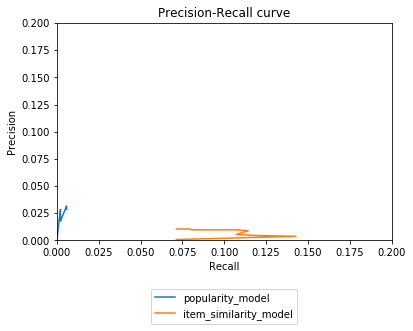

In [194]:
print("Plotting precision recall curves.")

plot_precision_recall(pm_avg_precision_list, pm_avg_recall_list, "popularity_model",
                      ism_avg_precision_list, ism_avg_recall_list, "item_similarity_model")

# Get Top 5 Recommendations

In [195]:
#Print the songs for the user in training data
user_id = df_train.userId.iloc[10]
print("----------------------------------------------------------------------")
print("Recommendation process going on:")
print("----------------------------------------------------------------------")

#Recommend songs for the user using personalized model
is_model.recommend(user_id, 5)

----------------------------------------------------------------------
Recommendation process going on:
----------------------------------------------------------------------
No. of unique products for the user: 122
no. of unique products in the training set: 17687
Non zero values in cooccurence_matrix :53156


,userId,productId,score,rank
0,A3NEAETOSXDBOM,B00FSDKBYY,0.040564,1
1,A3NEAETOSXDBOM,B00I9V8D92,0.040424,2
2,A3NEAETOSXDBOM,B00JZC972Q,0.036901,3
3,A3NEAETOSXDBOM,B00H8JYOG2,0.036859,4
4,A3NEAETOSXDBOM,B00JWXNT2M,0.036023,5


# Summary

Collabrative filtering is giving personalized recommendations to users. And seems to have better accuracy.